# Research: how fit error changes with the number of points

This notebook sweeps all detected injections across point counts up to each injection's full span, stores coefficient values and uncertainties, and saves separate comparison plots in `research/output`.

In [13]:
from pathlib import Path
import importlib.util
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pha_lib").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pha_lib")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

ADAPTIVE_PATH = ROOT / "adaptive points" / "adaptive point selection.py"
spec = importlib.util.spec_from_file_location("adaptive_point_selection", str(ADAPTIVE_PATH))
adaptive_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(adaptive_mod)

# INPUT = ROOT / "data" / "test" / "modified txt-s" / "unitedc_62_239.txt"
INPUT = ROOT / "data" / "test"
OUT_DIR = ROOT / "research" / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LINE_E = 6660.0
HALF_W = 60.0
CHANNEL_ID = 2
MIN_POINTS = 2

print(f"Project root: {ROOT}")
print(f"Output dir: {OUT_DIR}")
print(f"Input file: {INPUT}")

Project root: D:\ℱ Sci\IFPiLM\1st task
Output dir: D:\ℱ Sci\IFPiLM\1st task\research\output
Input file: D:\ℱ Sci\IFPiLM\1st task\data\test


In [14]:
discharge = io.load_test_folder(INPUT, discharge_id="united_62_239")
channel = discharge.channels[CHANNEL_ID]
trace = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

if not injections:
    raise RuntimeError("No injections detected for the chosen channel")

print(f"Loaded discharge: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injections detected")

injection_runs = []
for injection in injections:
    min_points = MIN_POINTS
    max_points = max(min_points, injection.finish_frame - injection.start_frame)
    print("")
    print(f"Using injection #{injection.injection_no} spanning frames {injection.start_frame}..{injection.finish_frame}")
    print(f"Sweeping point counts from {min_points} to {max_points} (full injection span)")

    rows = adaptive_mod.sweep_injection_point_counts(
        trace,
        injection,
        min_points=min_points,
        max_points=max_points,
    )
    df = pd.DataFrame(rows)

    cols_to_show = ["n_points", "success", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss", "message"]
    print(df[cols_to_show].to_string(index=False))

    csv_path = OUT_DIR / f"sweep_channel{CHANNEL_ID}_inj{injection.injection_no}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved table -> {csv_path}")

    success_df = df[df["success"]].copy()
    if not success_df.empty:
        best_row = success_df.sort_values("rss").iloc[0]
        print("")
        print("Best fit by RSS:")
        print(best_row[["n_points", "A", "A_err", "tau", "tau_err", "C", "C_err", "rss"]].to_string())

    injection_runs.append(
        {
            "injection": injection,
            "df": df,
            "min_points": min_points,
            "max_points": max_points,
        }
    )

Loaded discharge: united_62_239
Channel 2: 5 injections detected

Using injection #1 spanning frames 63..67
Sweeping point counts from 2 to 4 (full injection span)
 n_points  success          A     A_err       tau  tau_err    C  C_err         rss message
        2     True 171.000000       inf 84.999020      inf 58.0    0.0    0.000000      ok
        3     True 184.702405 47.719428  2.852852 2.280707 58.0    0.0 2464.899652      ok
        4     True 189.197765 38.286262  2.276727 1.021201 58.0    0.0 3271.884053      ok
Saved table -> D:\ℱ Sci\IFPiLM\1st task\research\output\sweep_channel2_inj1.csv

Best fit by RSS:
n_points           2
A              171.0
A_err            inf
tau         84.99902
tau_err          inf
C               58.0
C_err            0.0
rss              0.0

Using injection #2 spanning frames 99..111
Sweeping point counts from 2 to 12 (full injection span)
 n_points  success           A      A_err          tau      tau_err    C  C_err          rss message
    

D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_model, t_data, y_data, p0=p0, maxfev=5000)
D:\ℱ Sci\IFPiLM\1st task\adaptive points\adaptive point selection.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov =

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\plot_channel2_inj1.png


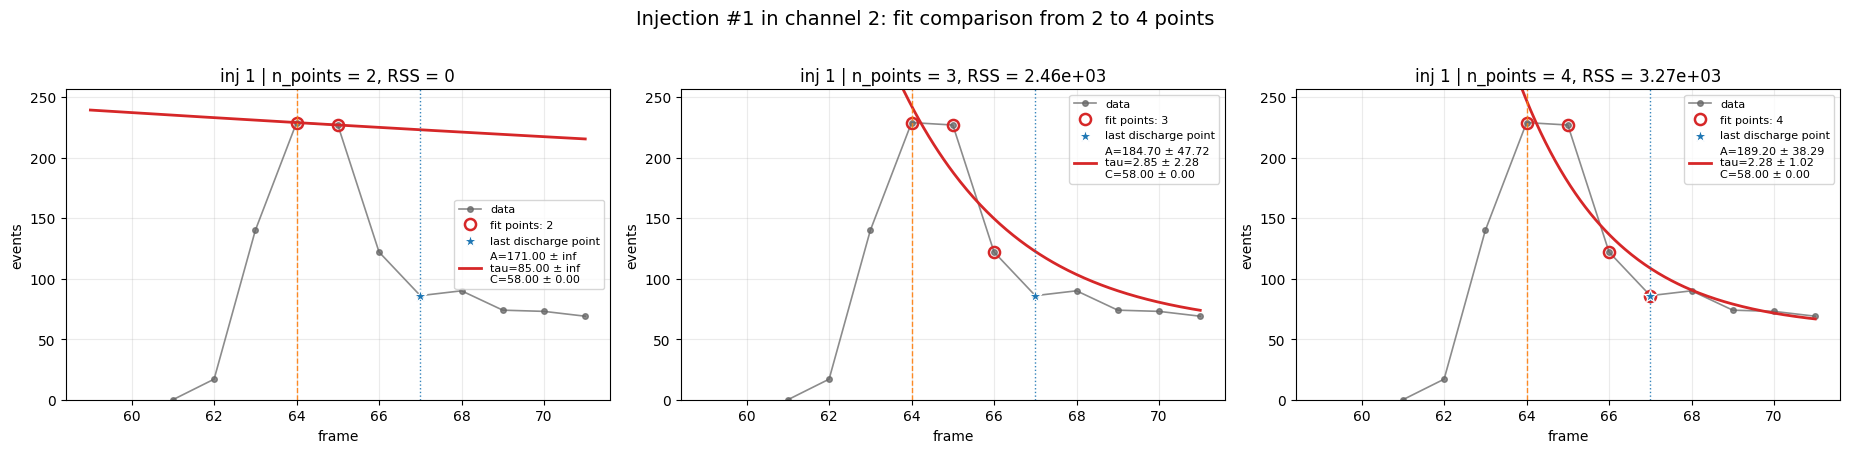

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\plot_channel2_inj2.png


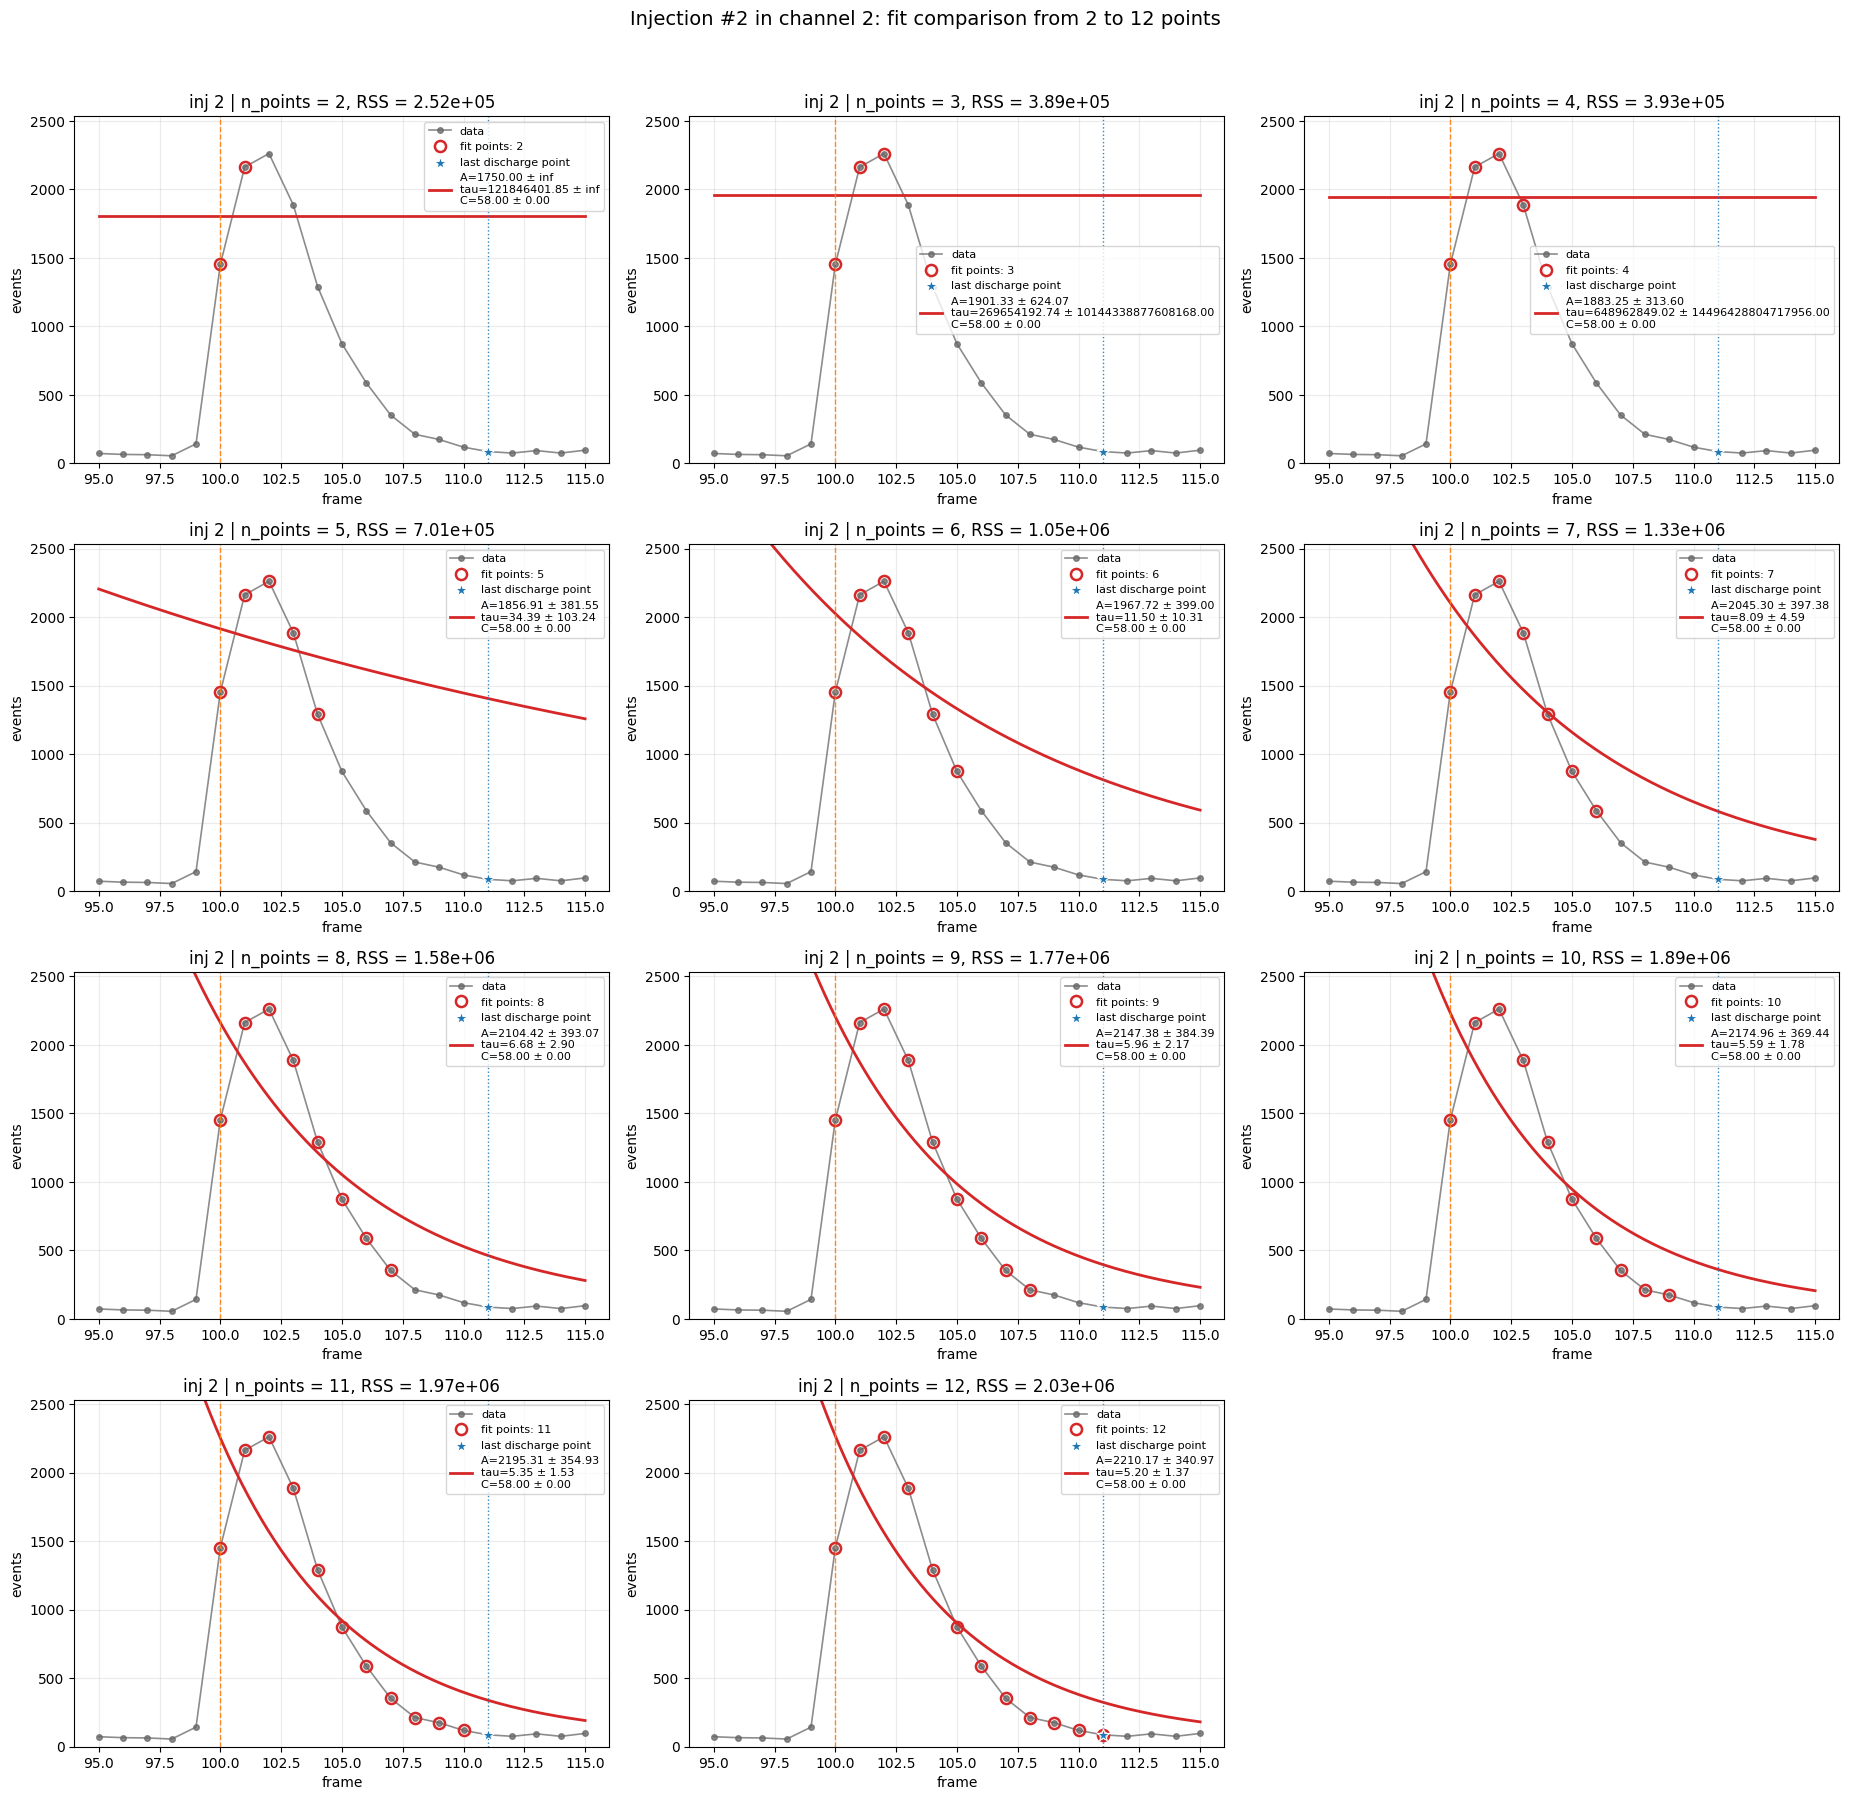

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\plot_channel2_inj3.png


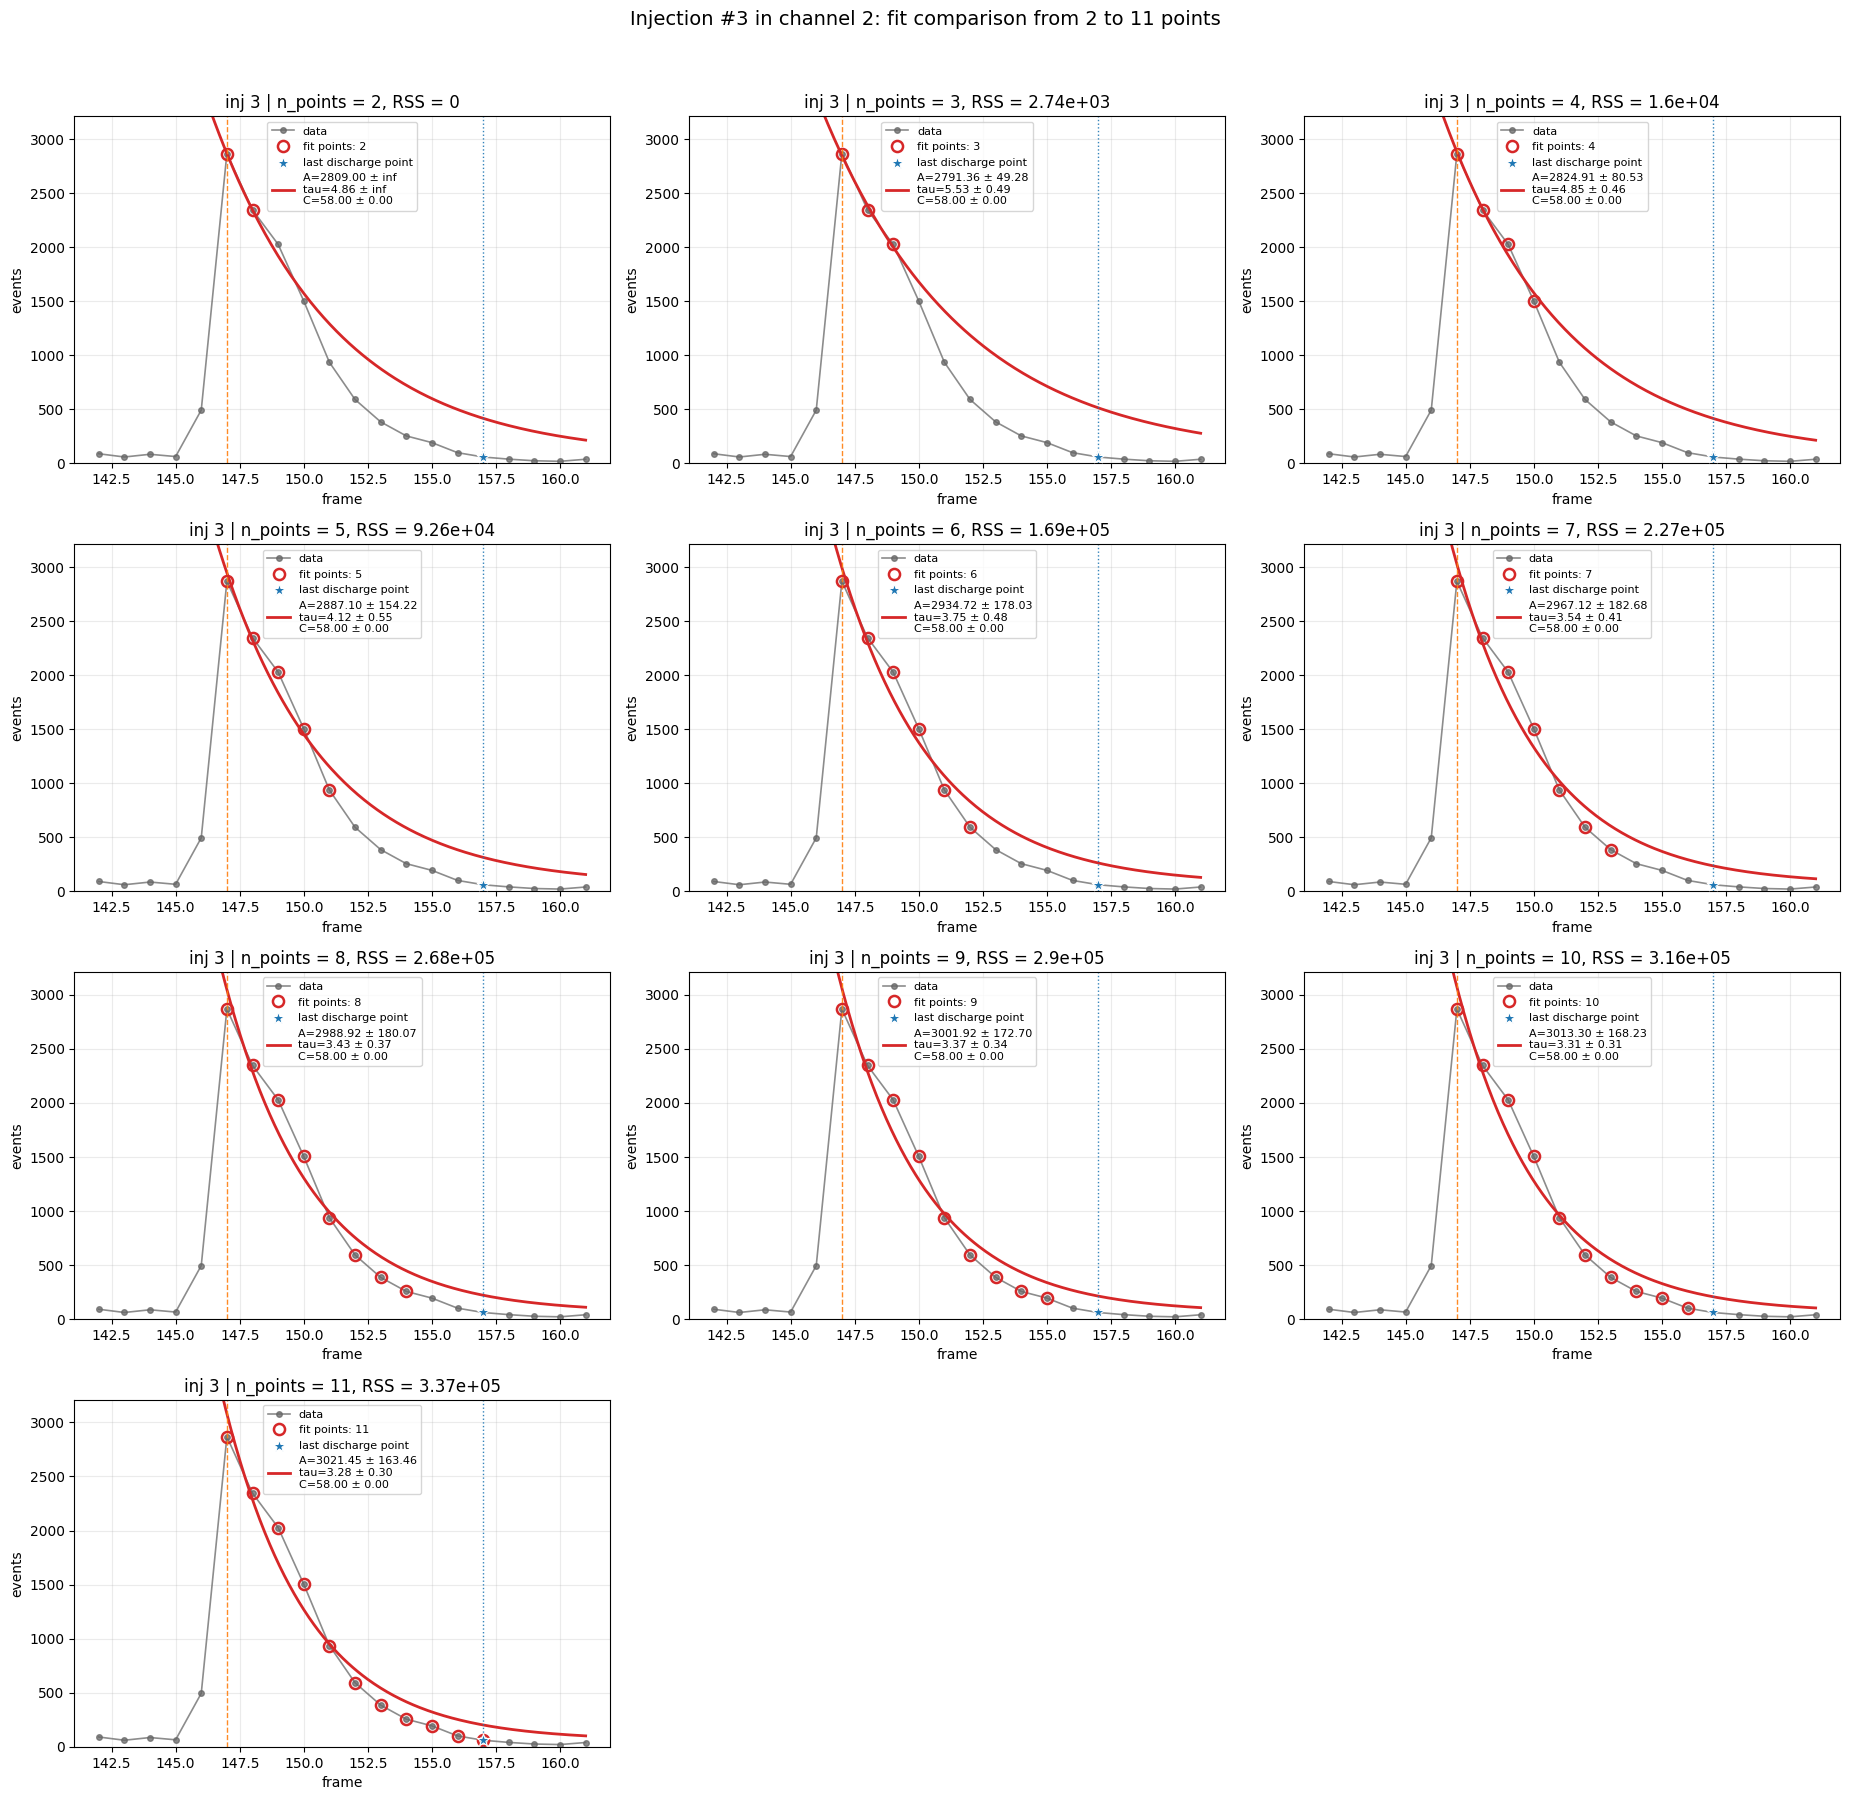

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\plot_channel2_inj4.png


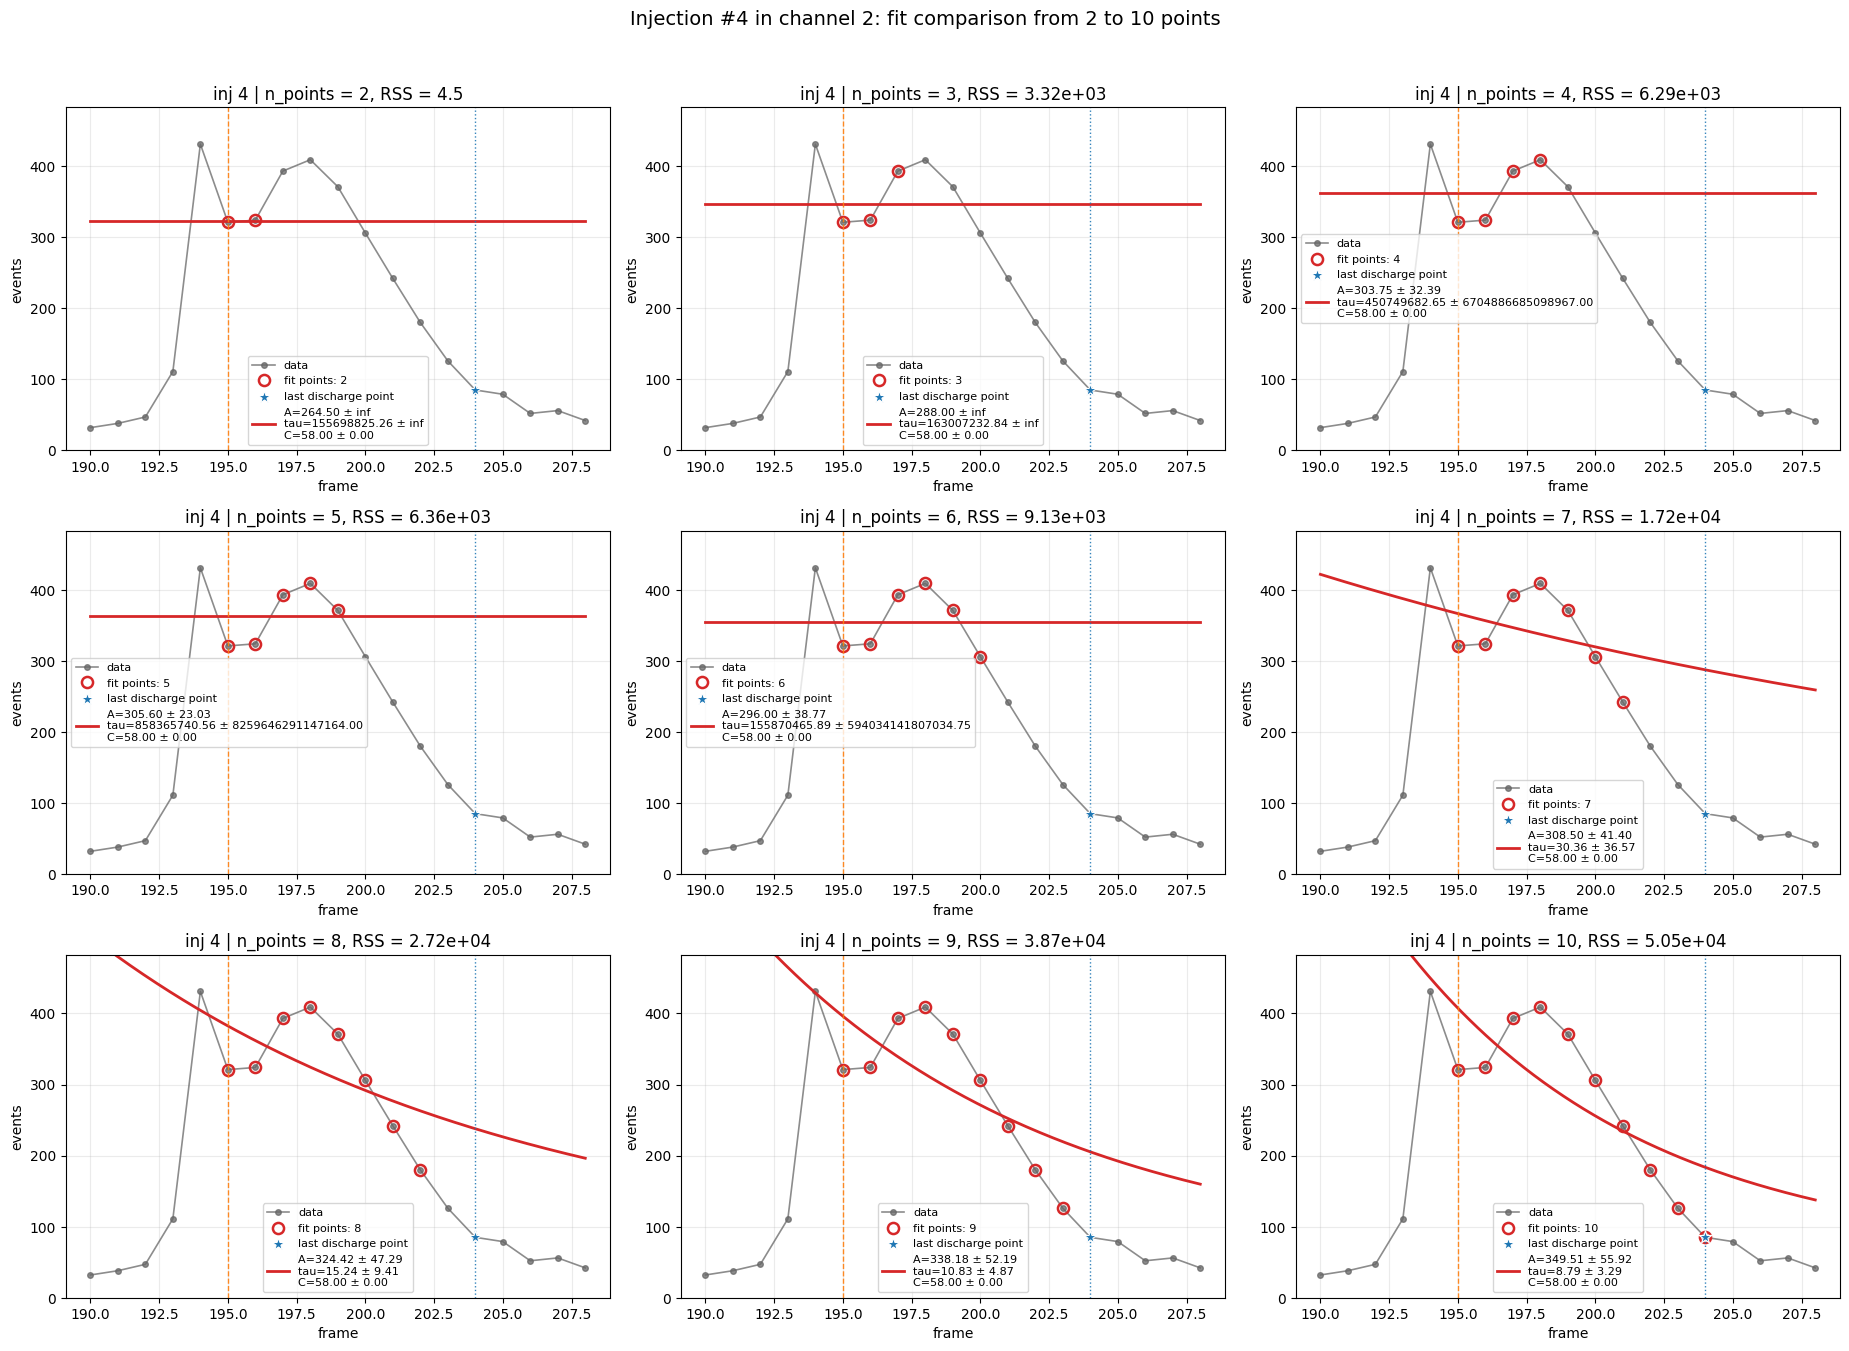

Saved figure -> D:\ℱ Sci\IFPiLM\1st task\research\output\plot_channel2_inj5.png


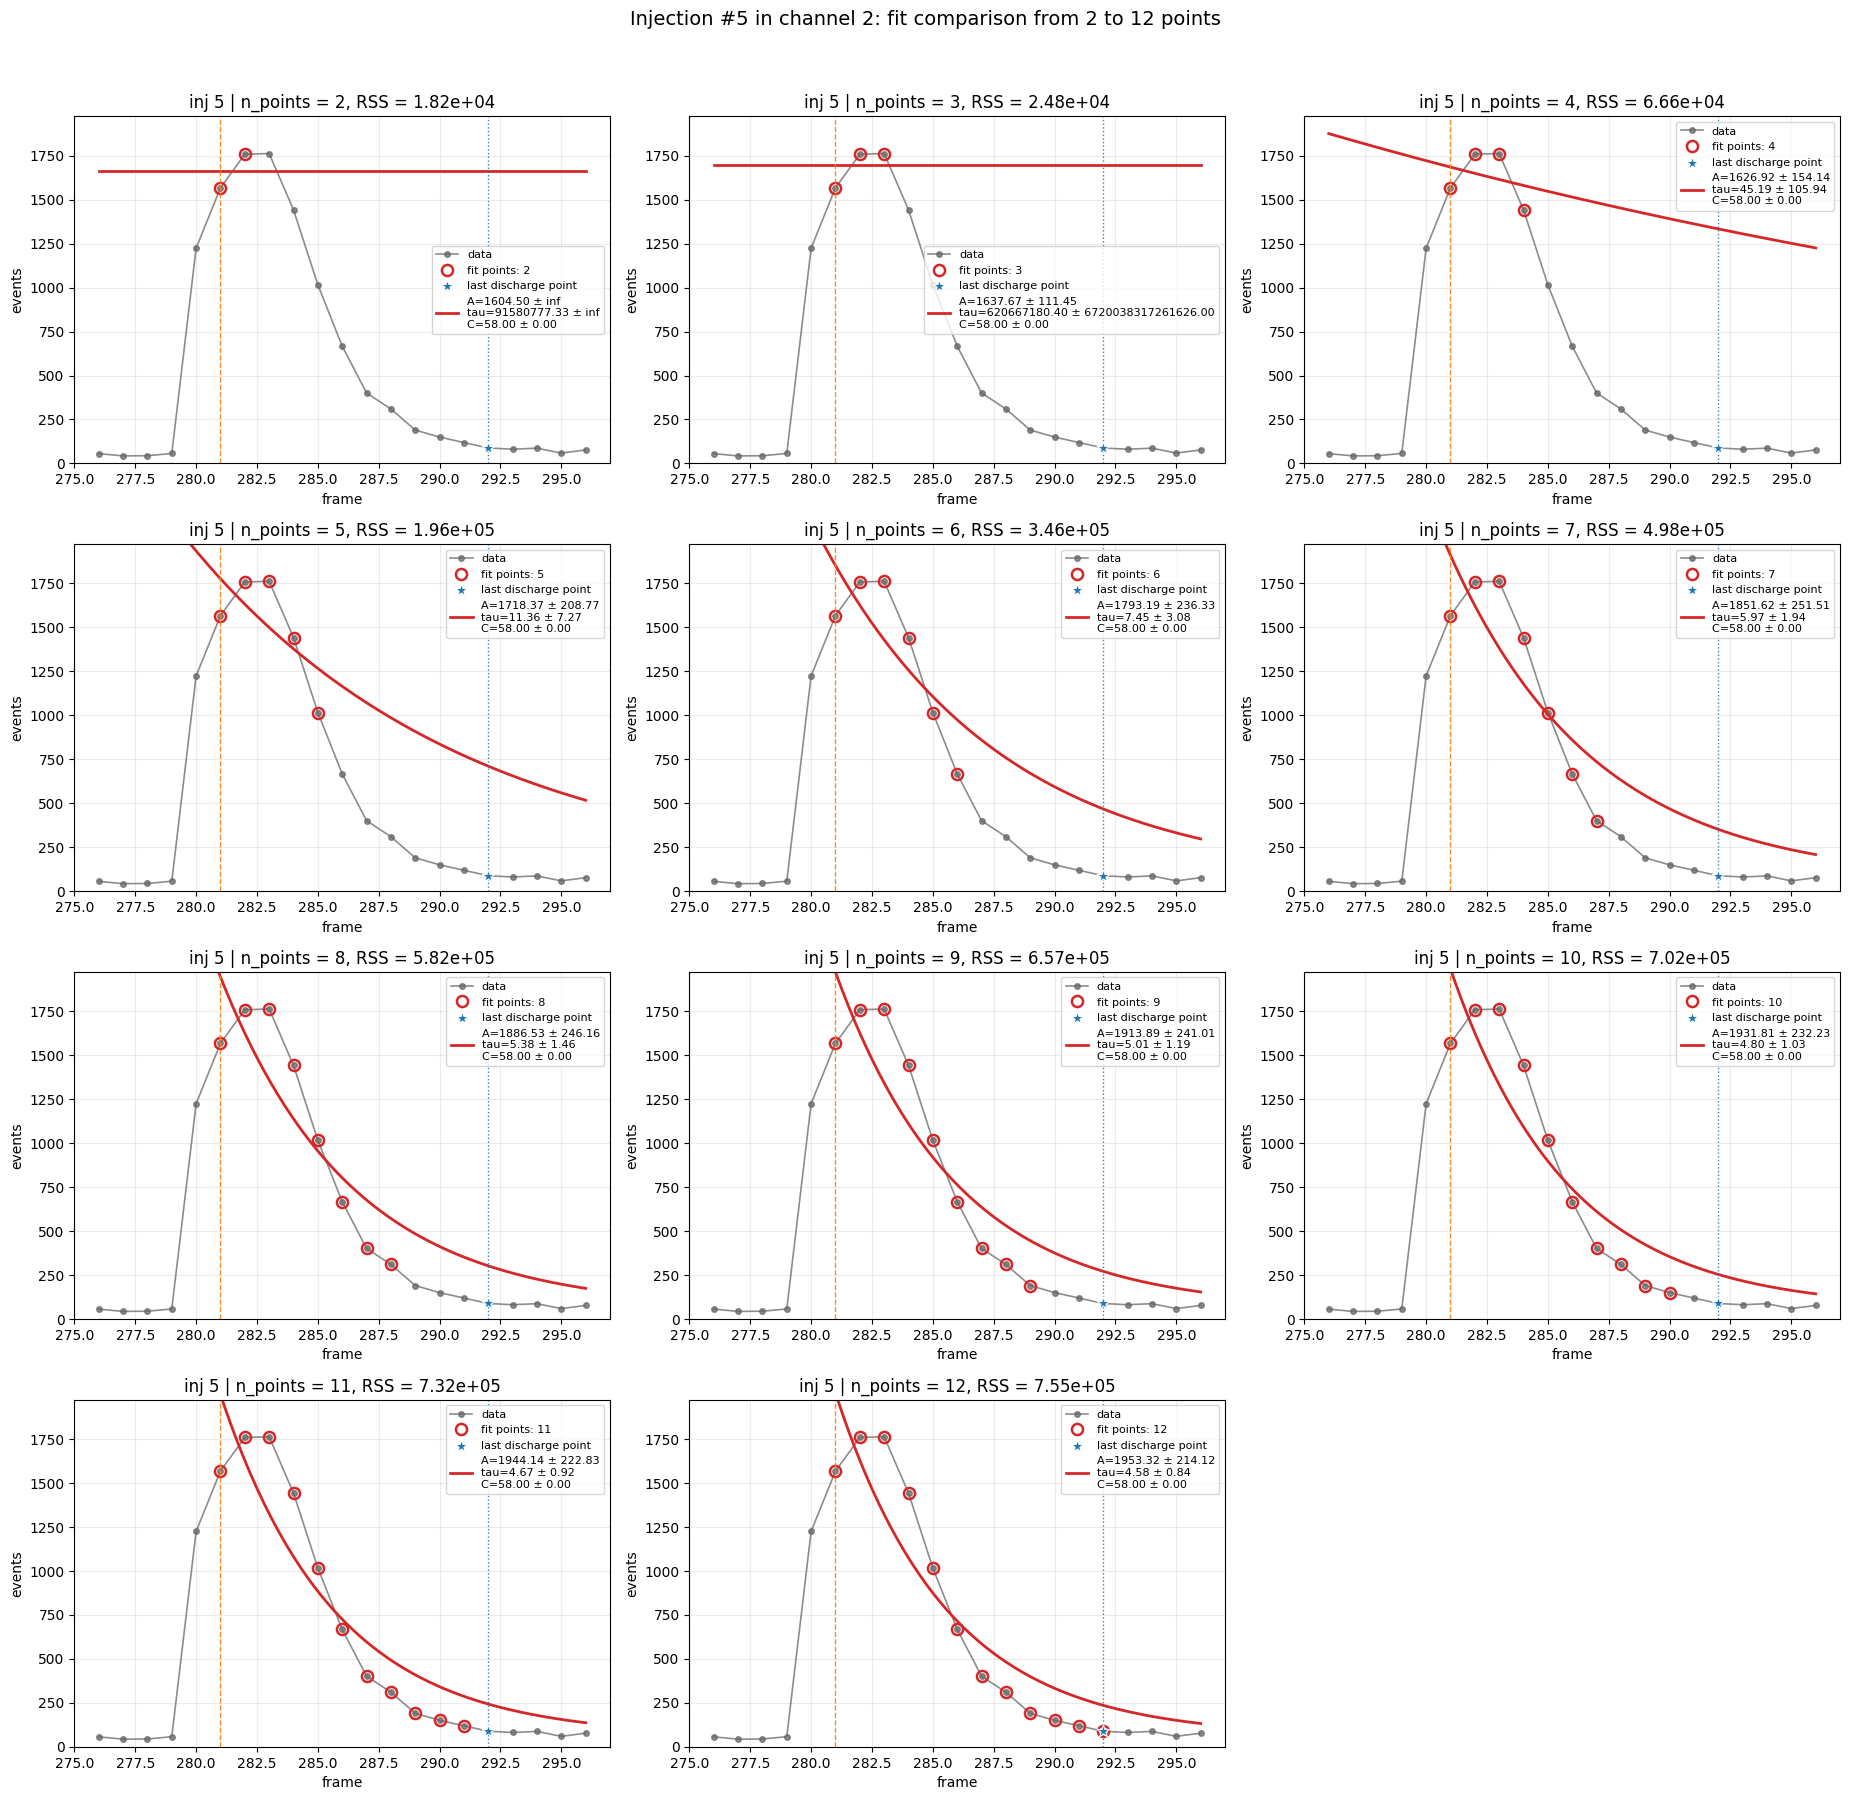

In [15]:
def format_value(value: float, error: float, digits: int = 2) -> str:
    if pd.isna(value):
        return "nan"
    if pd.isna(error):
        return f"{value:.{digits}f}"
    return f"{value:.{digits}f} ± {error:.{digits}f}"


if not injection_runs:
    raise RuntimeError("No injection runs available to plot")

for run in injection_runs:
    injection = run["injection"]
    df = run["df"]
    min_points = run["min_points"]
    max_points = run["max_points"]

    success_df = df[df["success"]].copy().reset_index(drop=True)
    if success_df.empty:
        print(f"Skipping injection #{injection.injection_no}: no successful fits")
        continue

    n_plots = len(success_df)
    max_cols = 3
    n_cols = min(max_cols, n_plots)
    n_rows = math.ceil(n_plots / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.4 * n_rows), squeeze=False)

    fn = trace.frame_numbers
    v = trace.values
    start_idx = int(np.where(fn == int(injection.start_frame + 1))[0][0])
    last_idx = int(np.where(fn == int(injection.finish_frame))[0][0])
    context_lo = max(0, injection.start_frame - 4)
    context_hi = min(int(fn[-1]), injection.finish_frame + 4)
    context_mask = (fn >= context_lo) & (fn <= context_hi)

    for ax, (_, row) in zip(axes.flat, success_df.iterrows()):
        n_points = int(row["n_points"])
        end_idx = min(start_idx + n_points, len(fn))
        t_data = fn[start_idx:end_idx].astype(float)
        y_data = v[start_idx:end_idx]
        t_dense = np.linspace(context_lo, context_hi, 300)
        y_fit = row["A"] * np.exp(-(t_dense - row["t_0"]) / row["tau"]) + row["C"]

        ax.plot(fn[context_mask], v[context_mask], "o-", ms=4, lw=1.2, color="0.4", alpha=0.75, label="data")
        ax.plot(t_data, y_data, "o", ms=8, mfc="none", mec="tab:red", mew=1.8, label=f"fit points: {n_points}")
        ax.scatter(
            [fn[last_idx]],
            [v[last_idx]],
            s=90,
            marker="*",
            color="tab:blue",
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
            label="last discharge point",
        )
        ax.plot(
            t_dense,
            y_fit,
            color="tab:red",
            lw=2,
            label=(
                f"A={format_value(row['A'], row['A_err'])}\n"
                f"tau={format_value(row['tau'], row['tau_err'])}\n"
                f"C={format_value(row['C'], row['C_err'])}"
            ),
        )
        y_visible = np.r_[v[context_mask], y_data, v[last_idx]]
        y_max = float(np.max(y_visible)) * 1.12
        ax.set_ylim(0.0, y_max)
        ax.axvline(injection.start_frame + 1, color="tab:orange", ls="--", lw=1, alpha=0.9)
        ax.axvline(injection.finish_frame, color="tab:blue", ls=":", lw=1, alpha=0.9)
        ax.set_title(f"inj {injection.injection_no} | n_points = {n_points}, RSS = {row['rss']:.3g}")
        ax.set_xlabel("frame")
        ax.set_ylabel("events")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    for ax in axes.flat[n_plots:]:
        ax.axis("off")

    fig.suptitle(
        f"Injection #{injection.injection_no} in channel {CHANNEL_ID}: fit comparison from {min_points} to {max_points} points",
        y=1.02,
        fontsize=14,
    )
    fig.tight_layout()

    fig_path = OUT_DIR / f"plot_channel{CHANNEL_ID}_inj{injection.injection_no}.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure -> {fig_path}")
    display(fig)
    plt.close(fig)